In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import importlib
import module
importlib.reload(module)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


METRIC_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
]


def buy_and_hold_curve(price_series):
    prices = price_series.to_numpy(dtype=float)

    curve = (
        prices
        / prices[0]
    )

    return pd.Series(
        curve,
        index=price_series.index
    )


def evaluate_signal_curve(price_series, signal_frame):
    delayed_signal_frame = module.apply_execution_delay(
        signal_frame,
        delay_days=1
    )

    strategy_values = module.single_signal_portfolio_values(
        price_values=price_series.to_numpy(dtype=float),
        signal_values=delayed_signal_frame["signal"].to_numpy(dtype=float),
        initial_value=1.0
    )

    strategy_curve = pd.Series(
        strategy_values,
        index=price_series.index
    )

    benchmark_curve = buy_and_hold_curve(price_series)

    strategy_stats = module.performance_statistics_from_values(
        strategy_curve.to_numpy(dtype=float)
    )

    benchmark_stats = module.performance_statistics_from_values(
        benchmark_curve.to_numpy(dtype=float)
    )

    return strategy_curve, benchmark_curve, strategy_stats, benchmark_stats


def signal_usage_statistics(signal_frame):
    signal = signal_frame["signal"].to_numpy(dtype=float)

    position_change = np.zeros(len(signal))
    position_change[1:] = np.abs(
        signal[1:]
        - signal[:-1]
    )

    active_share = np.sum(signal) / len(signal)
    number_of_trades = np.sum(position_change)

    return active_share, number_of_trades


def evaluate_candidate(price_series, signal_frame):
    strategy_curve, benchmark_curve, strategy_stats, benchmark_stats = evaluate_signal_curve(
        price_series,
        signal_frame
    )

    active_share, number_of_trades = signal_usage_statistics(
        signal_frame
    )

    strategy_stats["Active Share"] = active_share
    strategy_stats["Number of Trades"] = number_of_trades

    return strategy_stats, strategy_curve, benchmark_curve


def build_statistics_table(
    strategy_name,
    buy_hold_name,
    in_sample_stats,
    buy_hold_in_sample_stats,
    out_sample_stats,
    buy_hold_out_sample_stats,
    full_sample_stats,
    buy_hold_full_sample_stats
):
    df_statistics = pd.DataFrame(
        {
            strategy_name + " In-Sample": in_sample_stats,
            buy_hold_name + " In-Sample": buy_hold_in_sample_stats,
            strategy_name + " Out-of-Sample": out_sample_stats,
            buy_hold_name + " Out-of-Sample": buy_hold_out_sample_stats,
            strategy_name + " Full Sample": full_sample_stats,
            buy_hold_name + " Full Sample": buy_hold_full_sample_stats
        }
    ).T

    df_statistics = df_statistics[METRIC_COLUMNS]

    return df_statistics.round(4)


def plot_strategy_vs_buy_hold(
    strategy_curve,
    buy_hold_curve,
    title,
    strategy_label,
    buy_hold_label,
    out_of_sample_start
):
    plt.figure(figsize=(12, 5))

    plt.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label
    )

    plt.plot(
        buy_hold_curve.index,
        buy_hold_curve.to_numpy(dtype=float),
        label=buy_hold_label,
        linestyle="--"
    )

    plt.axvline(
        pd.Timestamp(out_of_sample_start),
        linestyle=":",
        label="Out-of-sample start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.grid(True)
    plt.show()

Matplotlib is building the font cache; this may take a moment.


# Research Notebook: In-Sample Calibration and Out-of-Sample Backtest of Three Trading Signals

This notebook evaluates three simple trading signals using daily close prices only.  
Each signal trades one ETF and is compared against buy-and-hold of the same ETF.

The three traded assets are:

1. SPY, using a VIX term-structure signal.
2. XLE, using crude oil momentum, XLE momentum, and XLE relative strength versus SPY.
3. GLD, using a gold trend, gold momentum, and Treasury bond momentum regime signal.

The sample is split into an in-sample calibration period and an out-of-sample evaluation period.  
The parameters are estimated only on the in-sample period.  
The selected parameter set is then evaluated in-sample, out-of-sample, and over the full sample.

The trading rule uses the same timing assumption as the backtest files:

$$
\text{Signal at close } t
\quad \Rightarrow \quad
\text{trade at close } t+1
$$

Therefore, a signal observed at close \(t\) earns the return from \(t+1\) to \(t+2\).  
This avoids look-ahead bias because the strategy never trades on information before it is available.

The basic momentum variable is:

$$
M_t^{(n)} = \frac{P_t}{P_{t-n}} - 1
$$

The moving average is:

$$
MA_t^{(n)} = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
$$

For every strategy and buy-and-hold benchmark, the following statistics are computed:

$$
R_{\text{ann}} =
\left(\frac{W_T}{W_0}\right)^{252/N} - 1
$$

$$
\sigma_{\text{ann}} =
\sqrt{252}\cdot \sigma(r_t)
$$

$$
\text{Sharpe} =
\frac{252\cdot \bar r}{\sigma_{\text{ann}}}
$$

$$
\text{Max Drawdown} =
\min_t \left(\frac{W_t}{\max_{s \leq t} W_s} - 1\right)
$$

In [2]:
PERIODS_PER_YEAR = 252

METRIC_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
]


def buy_and_hold_curve(price_series):
    prices = price_series.to_numpy(dtype=float)
    wealth = prices / prices[0]
    return pd.Series(wealth, index=price_series.index)


def evaluate_signal_curve(price_series, raw_signal_frame):
    delayed_signal_frame = module.apply_execution_delay(
        raw_signal_frame,
        delay_days=1
    )

    strategy_values = module.single_signal_portfolio_values(
        price_values=price_series.to_numpy(dtype=float),
        signal_values=delayed_signal_frame["signal"].to_numpy(dtype=float),
        initial_value=1.0
    )

    strategy_curve = pd.Series(
        strategy_values,
        index=price_series.index
    )

    buy_hold = buy_and_hold_curve(price_series)

    strategy_stats = module.performance_statistics_from_values(
        strategy_curve.to_numpy(dtype=float),
        periods_per_year=PERIODS_PER_YEAR
    )

    buy_hold_stats = module.performance_statistics_from_values(
        buy_hold.to_numpy(dtype=float),
        periods_per_year=PERIODS_PER_YEAR
    )

    return strategy_curve, buy_hold, strategy_stats, buy_hold_stats


def build_statistics_table(
    strategy_name,
    buy_hold_name,
    in_sample_stats,
    buy_hold_in_sample_stats,
    out_sample_stats,
    buy_hold_out_sample_stats,
    full_sample_stats,
    buy_hold_full_sample_stats
):
    df_statistics = pd.DataFrame(
        {
            strategy_name + " In-Sample": in_sample_stats,
            buy_hold_name + " In-Sample": buy_hold_in_sample_stats,
            strategy_name + " Out-of-Sample": out_sample_stats,
            buy_hold_name + " Out-of-Sample": buy_hold_out_sample_stats,
            strategy_name + " Full Sample": full_sample_stats,
            buy_hold_name + " Full Sample": buy_hold_full_sample_stats
        }
    ).T

    df_statistics = df_statistics[METRIC_COLUMNS]

    return df_statistics.round(4)


def plot_strategy_vs_buy_hold(
    strategy_curve,
    buy_hold_curve,
    title,
    strategy_label,
    buy_hold_label,
    out_of_sample_start
):
    plt.figure(figsize=(12, 5))

    plt.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label
    )

    plt.plot(
        buy_hold_curve.index,
        buy_hold_curve.to_numpy(dtype=float),
        label=buy_hold_label,
        linestyle="--"
    )

    plt.axvline(
        pd.Timestamp(out_of_sample_start),
        linestyle=":",
        label="Out-of-sample start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.grid(True)
    plt.show()

# Signal 0: SPY / VIX Term-Structure Strategy

This signal trades SPY.  
The information variables are spot VIX and VIX3M.

The academic motivation is that the VIX futures term structure contains information about future equity-market conditions. Fassas and Hourvouliades (2019, p. 1) state that the VIX term structure can be used not only as a proxy for forward volatility expectations, but also as a stock-market timing tool. They also describe the difference between contango and backwardation in the VIX term structure. Fassas (2012, p. 3) argues that the VIX futures term structure may contain more equity-market information than spot VIX alone.

The signal also uses time-series momentum. Moskowitz, Ooi and Pedersen (2012, p. 228) document time-series momentum across equity index, currency, commodity and bond futures, with return persistence over one to twelve months.

The VIX ratio is:

$$
R_t^{VIX} = \frac{VIX3M_t}{VIX_t}
$$

The SPY momentum filter is:

$$
M_t^{SPY} = \frac{SPY_t}{SPY_{t-168}} - 1
$$

The signal is:

$$
S_t^{SPY} =
\begin{cases}
1, & \text{if } R_t^{VIX} > 1.10 \text{ and } M_t^{SPY} > -0.025 \\
0, & \text{otherwise}
\end{cases}
$$

The selected parameters are:

$$
R_t^{VIX} > 1.10,
\qquad
M_t^{SPY,168} > -0.025
$$

Signal 0 top 10 parameter combinations:


,Ratio Threshold,Momentum Window,Momentum Threshold,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Rank
0,1.10,168,-0.025,0.0561,0.0722,0.7928,-0.0764,0.3839,188.0,1
1,1.10,168,-0.050,0.0553,0.0732,0.7721,-0.0947,0.3928,186.0,2
2,1.10,252,-0.025,0.0532,0.0717,0.7582,-0.1006,0.3796,158.0,3
3,1.10,63,0.025,0.0469,0.0635,0.7541,-0.0760,0.3510,180.0,4
4,1.00,126,0.025,0.0716,0.0983,0.7531,-0.1722,0.5903,101.0,5
5,0.90,126,0.025,0.0761,0.1058,0.7468,-0.2091,0.6307,53.0,6
6,0.85,126,0.025,0.0755,0.1061,0.7396,-0.2114,0.6330,47.0,7
7,1.10,252,-0.050,0.0520,0.0721,0.7392,-0.1006,0.3820,160.0,8
8,0.90,168,0.000,0.0809,0.1150,0.7343,-0.1735,0.6640,51.0,9
9,1.10,252,0.000,0.0503,0.0709,0.7285,-0.0955,0.3778,160.0,10


Selected Signal 0 parameters:
Ratio threshold: 1.1
Momentum window: 168
Momentum threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
SPY VIX Strategy In-Sample,0.0561,0.0722,0.7928,-0.0764
Buy and Hold SPY In-Sample,0.0847,0.2164,0.4837,-0.5519
SPY VIX Strategy Out-of-Sample,0.0720,0.0818,0.8918,-0.1770
Buy and Hold SPY Out-of-Sample,0.1354,0.1779,0.8033,-0.3372
SPY VIX Strategy Full Sample,0.0613,0.0797,0.7863,-0.1770
Buy and Hold SPY Full Sample,0.1130,0.1956,0.6453,-0.5519


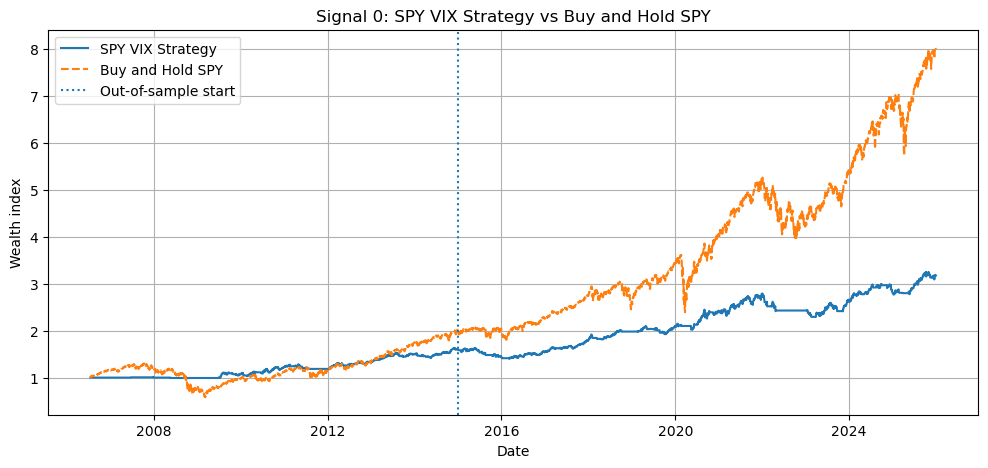

In [3]:
# ============================================================
# Signal 0: SPY / VIX term-structure strategy
# Parameter estimation and evaluation
# ============================================================

signal_0_tickers = [
    "SPY",
    "^VIX",
    "^VIX3M"
]

signal_0_start_date = "2004-01-01"
signal_0_end_date = "2025-12-31"

signal_0_in_sample_start = "2006-07-17"
signal_0_in_sample_end = "2014-12-31"

signal_0_out_sample_start = "2015-01-01"
signal_0_out_sample_end = "2025-12-31"

df_signal_0_prices, _ = module.download_stock_price_data(
    signal_0_tickers,
    signal_0_start_date,
    signal_0_end_date
)

spy_series = df_signal_0_prices["SPY"]
vix_series = df_signal_0_prices["^VIX"]
vix3m_series = df_signal_0_prices["^VIX3M"]

spy_in_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_in_sample_end
]

spy_out_sample = spy_series.loc[
    signal_0_out_sample_start:signal_0_out_sample_end
]

spy_full_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_out_sample_end
]

ratio_thresholds = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
momentum_windows = [63, 126, 168, 210, 252]
momentum_thresholds = [-0.05, -0.025, 0.00, 0.025, 0.05]

calibration_results = []

for ratio_threshold in ratio_thresholds:
    for momentum_window in momentum_windows:
        for momentum_threshold in momentum_thresholds:

            signal_frame = module.vix_term_structure_signal(
                target_series=spy_in_sample,
                vix_series=vix_series,
                vix3m_series=vix3m_series,
                ratio_threshold=ratio_threshold,
                momentum_window=momentum_window,
                momentum_threshold=momentum_threshold
            )

            stats, _, _ = evaluate_candidate(
                spy_in_sample,
                signal_frame
            )

            stats["Ratio Threshold"] = ratio_threshold
            stats["Momentum Window"] = momentum_window
            stats["Momentum Threshold"] = momentum_threshold

            calibration_results.append(stats)

df_signal_0_results = pd.DataFrame(calibration_results)

df_signal_0_results = df_signal_0_results[
    [
        "Ratio Threshold",
        "Momentum Window",
        "Momentum Threshold",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
        "Active Share",
        "Number of Trades"
    ]
]

df_signal_0_results = df_signal_0_results.sort_values(
    by="Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

df_signal_0_results["Rank"] = np.arange(1, len(df_signal_0_results) + 1)

print("Signal 0 top 10 parameter combinations:")
display(df_signal_0_results.head(10).round(4))

best_signal_0 = df_signal_0_results.iloc[0]

signal_0_ratio_threshold = float(best_signal_0["Ratio Threshold"])
signal_0_momentum_window = int(best_signal_0["Momentum Window"])
signal_0_momentum_threshold = float(best_signal_0["Momentum Threshold"])

print("Selected Signal 0 parameters:")
print("Ratio threshold:", signal_0_ratio_threshold)
print("Momentum window:", signal_0_momentum_window)
print("Momentum threshold:", signal_0_momentum_threshold)


def make_signal_0(price_series):
    return module.vix_term_structure_signal(
        target_series=price_series,
        vix_series=vix_series,
        vix3m_series=vix3m_series,
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )


signal_0_in = make_signal_0(spy_in_sample)
signal_0_out = make_signal_0(spy_out_sample)
signal_0_full = make_signal_0(spy_full_sample)

strategy_0_in, buy_hold_0_in, stats_0_in, bh_0_in = evaluate_signal_curve(
    spy_in_sample,
    signal_0_in
)

strategy_0_out, buy_hold_0_out, stats_0_out, bh_0_out = evaluate_signal_curve(
    spy_out_sample,
    signal_0_out
)

strategy_0_full, buy_hold_0_full, stats_0_full, bh_0_full = evaluate_signal_curve(
    spy_full_sample,
    signal_0_full
)

df_signal_0_statistics = build_statistics_table(
    strategy_name="SPY VIX Strategy",
    buy_hold_name="Buy and Hold SPY",
    in_sample_stats=stats_0_in,
    buy_hold_in_sample_stats=bh_0_in,
    out_sample_stats=stats_0_out,
    buy_hold_out_sample_stats=bh_0_out,
    full_sample_stats=stats_0_full,
    buy_hold_full_sample_stats=bh_0_full
)

display(df_signal_0_statistics)

plot_strategy_vs_buy_hold(
    strategy_curve=strategy_0_full,
    buy_hold_curve=buy_hold_0_full,
    title="Signal 0: SPY VIX Strategy vs Buy and Hold SPY",
    strategy_label="SPY VIX Strategy",
    buy_hold_label="Buy and Hold SPY",
    out_of_sample_start=signal_0_out_sample_start
)

# Signal 1: Oil / Energy Relative-Strength Strategy

This signal trades XLE. Crude oil futures and SPY are only used as information variables.

The economic idea is that energy equities should perform better when the energy sector is in an upward trend, crude oil momentum is supportive, and XLE shows relative strength compared with the broad equity market.

The basic momentum variable is:

$$
M_t^{(n)} = \frac{P_t}{P_{t-n}} - 1
$$

The XLE trend condition is:

$$
XLE_t > MA_t^{XLE,n}
$$

The oil momentum condition is:

$$
M_t^{Oil} = \frac{Oil_t}{Oil_{t-m}} - 1 > q
$$

The XLE momentum condition is:

$$
M_t^{XLE} = \frac{XLE_t}{XLE_{t-k}} - 1 > r
$$

The relative-strength ratio is:

$$
RS_t^{XLE/SPY} = \frac{XLE_t}{SPY_t}
$$

and the relative-strength momentum is:

$$
M_t^{RS} =
\frac{RS_t^{XLE/SPY}}{RS_{t-l}^{XLE/SPY}} - 1
$$

The final signal is:

$$
S_t^{XLE}
=
\begin{cases}
1, & \text{if trend, oil momentum, XLE momentum and relative strength conditions are satisfied} \\
0, & \text{otherwise}
\end{cases}
$$

The parameters are estimated only on the in-sample period and then evaluated out of sample.

Signal 1 top 10 parameter combinations:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Oil Momentum Window,Oil Momentum Threshold,Target Momentum Window,Target Momentum Threshold,Relative Strength Window,Relative Strength Threshold,Calibration Score,Rank
0,0.0905,0.1444,0.6727,-0.2206,0.4411,182.0,200,126,-0.05,210,0.000,21,-0.025,0.7633,1
1,0.0881,0.1421,0.6657,-0.2444,0.4133,146.0,150,126,-0.05,210,0.025,63,-0.025,0.7538,2
2,0.0855,0.1417,0.6501,-0.2206,0.4358,192.0,150,126,-0.05,210,0.000,21,-0.025,0.7355,3
3,0.0853,0.1425,0.6456,-0.2444,0.4191,156.0,150,126,-0.05,210,0.000,63,-0.025,0.7308,4
4,0.0843,0.1410,0.6449,-0.2468,0.4283,176.0,150,126,-0.05,210,0.025,21,-0.025,0.7292,5
5,0.0855,0.1440,0.6418,-0.2345,0.4344,166.0,200,126,-0.05,210,0.025,21,-0.025,0.7273,6
6,0.0837,0.1412,0.6400,-0.2444,0.4086,148.0,150,126,-0.05,210,0.050,63,-0.025,0.7236,7
7,0.0807,0.1398,0.6253,-0.2224,0.4230,180.0,150,126,-0.05,210,0.050,21,-0.025,0.7060,8
8,0.0805,0.1401,0.6228,-0.2363,0.4019,140.0,150,126,-0.05,210,0.075,63,-0.025,0.7033,9
9,0.0795,0.1392,0.6197,-0.2461,0.3644,92.0,150,126,-0.05,210,0.025,126,0.000,0.6992,10


Signal 1 selection method:
Best calibration score after robustness filters
Selected Signal 1 parameters:
Trend window: 200
Oil momentum window: 126
Oil momentum threshold: -0.05
Target momentum window: 210
Target momentum threshold: 0.0
Relative strength window: 21
Relative strength threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Oil Energy Strategy In-Sample,0.0905,0.1444,0.6727,-0.2206
Buy and Hold XLE In-Sample,0.0807,0.2852,0.4153,-0.5736
Oil Energy Strategy Out-of-Sample,0.0453,0.1356,0.3950,-0.4228
Buy and Hold XLE Out-of-Sample,0.0523,0.2937,0.3216,-0.6681
Oil Energy Strategy Full Sample,0.0706,0.1406,0.5560,-0.4228
Buy and Hold XLE Full Sample,0.0685,0.2889,0.3745,-0.7126


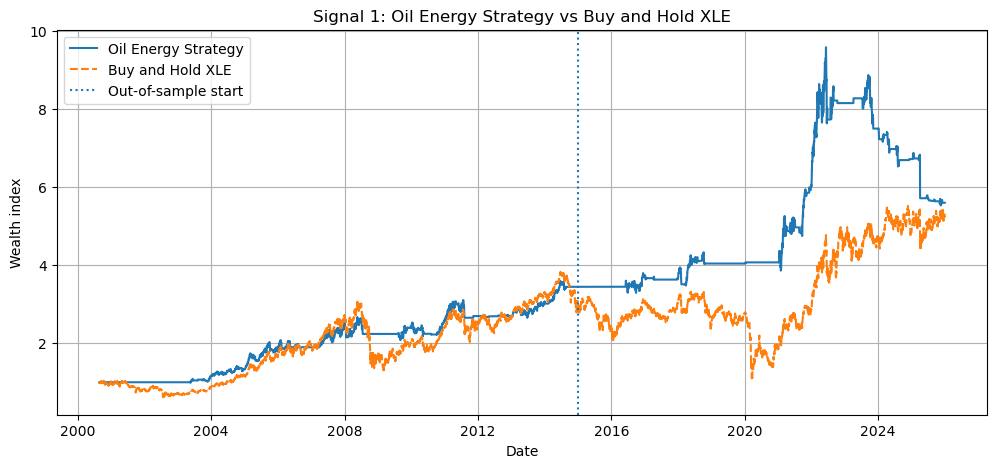

In [4]:
# ============================================================
# Signal 1: Oil / Energy relative-strength strategy
# ============================================================

signal_1_tickers = ["XLE", "CL=F", "SPY"]

signal_1_start_date = "2000-01-01"
signal_1_end_date = "2025-12-31"

signal_1_in_sample_start = "2000-01-01"
signal_1_in_sample_end = "2014-12-31"

signal_1_out_sample_start = "2015-01-01"
signal_1_out_sample_end = "2025-12-31"

df_signal_1_prices, _ = module.download_stock_price_data(
    signal_1_tickers,
    signal_1_start_date,
    signal_1_end_date
)

xle_series = df_signal_1_prices["XLE"]
oil_series = df_signal_1_prices["CL=F"]
market_series = df_signal_1_prices["SPY"]

xle_in_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

oil_in_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

market_in_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

xle_out_sample = xle_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

oil_out_sample = oil_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

market_out_sample = market_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

xle_full_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

oil_full_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

market_full_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]


# ============================================================
# Parameter grid
# ============================================================

trend_windows = [100, 150, 200, 250]

oil_momentum_windows = [21, 63, 126]
oil_momentum_thresholds = [-0.05, 0.00, 0.05, 0.10]

target_momentum_windows = [63, 126, 168, 210]
target_momentum_thresholds = [0.00, 0.025, 0.05, 0.075]

relative_strength_windows = [21, 63, 126]
relative_strength_thresholds = [-0.025, 0.00, 0.025, 0.05]


# ============================================================
# In-sample calibration
# ============================================================

calibration_results = []

for trend_window in trend_windows:
    for oil_momentum_window in oil_momentum_windows:
        for oil_momentum_threshold in oil_momentum_thresholds:
            for target_momentum_window in target_momentum_windows:
                for target_momentum_threshold in target_momentum_thresholds:
                    for relative_strength_window in relative_strength_windows:
                        for relative_strength_threshold in relative_strength_thresholds:

                            signal_frame = module.oil_energy_relative_strength_signal(
                                target_series=xle_in_sample,
                                oil_series=oil_in_sample,
                                market_series=market_in_sample,
                                trend_window=trend_window,
                                oil_momentum_window=oil_momentum_window,
                                oil_momentum_threshold=oil_momentum_threshold,
                                target_momentum_window=target_momentum_window,
                                target_momentum_threshold=target_momentum_threshold,
                                relative_strength_window=relative_strength_window,
                                relative_strength_threshold=relative_strength_threshold
                            )

                            stats, _, _ = evaluate_candidate(
                                xle_in_sample,
                                signal_frame
                            )

                            stats["Trend Window"] = trend_window
                            stats["Oil Momentum Window"] = oil_momentum_window
                            stats["Oil Momentum Threshold"] = oil_momentum_threshold
                            stats["Target Momentum Window"] = target_momentum_window
                            stats["Target Momentum Threshold"] = target_momentum_threshold
                            stats["Relative Strength Window"] = relative_strength_window
                            stats["Relative Strength Threshold"] = relative_strength_threshold

                            calibration_results.append(stats)


df_signal_1_results = pd.DataFrame(calibration_results)

df_signal_1_results["Calibration Score"] = (
    df_signal_1_results["Sharpe Ratio"]
    + df_signal_1_results["Annualized Return"]
)

df_signal_1_results = df_signal_1_results.sort_values(
    by="Calibration Score",
    ascending=False
).reset_index(drop=True)

df_signal_1_results["Rank"] = np.arange(
    1,
    len(df_signal_1_results) + 1
)

print("Signal 1 top 10 parameter combinations:")
display(df_signal_1_results.head(10).round(4))


# ============================================================
# Robustness filters
# ============================================================

df_signal_1_reasonable = df_signal_1_results[
    (df_signal_1_results["Active Share"] >= 0.20)
    & (df_signal_1_results["Active Share"] <= 0.95)
    & (df_signal_1_results["Max Drawdown"] >= -0.50)
    & (df_signal_1_results["Number of Trades"] <= 700)
].copy()

if len(df_signal_1_reasonable) > 0:
    best_signal_1 = df_signal_1_reasonable.iloc[0]
    selection_method_1 = "Best calibration score after robustness filters"
else:
    best_signal_1 = df_signal_1_results.iloc[0]
    selection_method_1 = "Best calibration score without filters"

print("Signal 1 selection method:")
print(selection_method_1)


# ============================================================
# Selected parameters
# ============================================================

signal_1_trend_window = int(best_signal_1["Trend Window"])

signal_1_oil_momentum_window = int(best_signal_1["Oil Momentum Window"])
signal_1_oil_momentum_threshold = float(best_signal_1["Oil Momentum Threshold"])

signal_1_target_momentum_window = int(best_signal_1["Target Momentum Window"])
signal_1_target_momentum_threshold = float(best_signal_1["Target Momentum Threshold"])

signal_1_relative_strength_window = int(best_signal_1["Relative Strength Window"])
signal_1_relative_strength_threshold = float(best_signal_1["Relative Strength Threshold"])

print("Selected Signal 1 parameters:")
print("Trend window:", signal_1_trend_window)
print("Oil momentum window:", signal_1_oil_momentum_window)
print("Oil momentum threshold:", signal_1_oil_momentum_threshold)
print("Target momentum window:", signal_1_target_momentum_window)
print("Target momentum threshold:", signal_1_target_momentum_threshold)
print("Relative strength window:", signal_1_relative_strength_window)
print("Relative strength threshold:", signal_1_relative_strength_threshold)


# ============================================================
# Evaluation with selected parameters
# ============================================================

def make_signal_1(price_series, oil_info_series, market_info_series):

    return module.oil_energy_relative_strength_signal(
        target_series=price_series,
        oil_series=oil_info_series,
        market_series=market_info_series,
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )


signal_1_in = make_signal_1(
    xle_in_sample,
    oil_in_sample,
    market_in_sample
)

signal_1_out = make_signal_1(
    xle_out_sample,
    oil_out_sample,
    market_out_sample
)

signal_1_full = make_signal_1(
    xle_full_sample,
    oil_full_sample,
    market_full_sample
)


strategy_1_in, buy_hold_1_in, stats_1_in, bh_1_in = evaluate_signal_curve(
    xle_in_sample,
    signal_1_in
)

strategy_1_out, buy_hold_1_out, stats_1_out, bh_1_out = evaluate_signal_curve(
    xle_out_sample,
    signal_1_out
)

strategy_1_full, buy_hold_1_full, stats_1_full, bh_1_full = evaluate_signal_curve(
    xle_full_sample,
    signal_1_full
)


df_signal_1_statistics = build_statistics_table(
    strategy_name="Oil Energy Strategy",
    buy_hold_name="Buy and Hold XLE",
    in_sample_stats=stats_1_in,
    buy_hold_in_sample_stats=bh_1_in,
    out_sample_stats=stats_1_out,
    buy_hold_out_sample_stats=bh_1_out,
    full_sample_stats=stats_1_full,
    buy_hold_full_sample_stats=bh_1_full
)

display(df_signal_1_statistics)


plot_strategy_vs_buy_hold(
    strategy_curve=strategy_1_full,
    buy_hold_curve=buy_hold_1_full,
    title="Signal 1: Oil Energy Strategy vs Buy and Hold XLE",
    strategy_label="Oil Energy Strategy",
    buy_hold_label="Buy and Hold XLE",
    out_of_sample_start=signal_1_out_sample_start
)

# Signal 2: Gold Regime Strategy

This signal trades GLD.  
TLT is only used as an information variable and is not traded directly.

The economic idea is that gold can behave differently from equities and energy stocks. Gold may benefit during periods of macroeconomic uncertainty, falling real-rate expectations, or demand for alternative safe-haven assets. However, the strategy should not hold gold permanently. It only buys GLD when gold itself is in an upward trend and when the bond market does not indicate a strongly unfavorable interest-rate environment.

The GLD trend condition is:

$$
GLD_t > MA_t^{GLD,n}
$$

The GLD momentum variable is:

$$
M_t^{GLD} = \frac{GLD_t}{GLD_{t-m}} - 1
$$

The Treasury bond momentum variable is:

$$
M_t^{TLT} = \frac{TLT_t}{TLT_{t-b}} - 1
$$

The final signal is:

$$
S_t^{GLD}
=
\begin{cases}
1, & \text{if GLD trend, GLD momentum and TLT momentum conditions are satisfied} \\
0, & \text{otherwise}
\end{cases}
$$

The parameters are estimated only on the in-sample period and then evaluated out of sample.

The Gold Regime Signal is designed to identify periods in which gold shows a positive investment regime. The signal is active when three conditions are fulfilled: first, the gold price is above its long-term moving average, which indicates an upward trend. Second, gold has positive medium-term momentum, meaning that the recent price development is supportive. Third, bond momentum is not strongly negative, because weak bond performance can signal an environment that is less favorable for defensive assets. If all three conditions are met, the strategy holds GLD; otherwise, it stays out of the market.
    

Signal 2 top 10 parameter combinations:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Gold Momentum Window,Gold Momentum Threshold,Bond Momentum Window,Bond Momentum Threshold,Calibration Score,Rank
0,0.0911,0.1065,0.8719,-0.1463,0.2884,120.0,100,63,0.025,63,0.00,0.9630,1
1,0.0964,0.1169,0.8464,-0.1886,0.3397,138.0,100,63,0.025,63,-0.02,0.9428,2
2,0.0970,0.1224,0.8176,-0.1725,0.4005,152.0,100,63,0.000,63,-0.02,0.9146,3
3,0.0814,0.1114,0.7580,-0.1514,0.3381,136.0,100,63,0.000,63,0.00,0.8394,4
4,0.0778,0.1064,0.7579,-0.1593,0.2833,106.0,150,63,0.025,63,0.00,0.8358,5
5,0.0831,0.1168,0.7424,-0.1942,0.3345,124.0,150,63,0.025,63,-0.02,0.8256,6
6,0.0750,0.1045,0.7449,-0.1537,0.2618,108.0,250,63,0.025,63,0.00,0.8200,7
7,0.0762,0.1065,0.7425,-0.1537,0.2733,110.0,200,63,0.025,63,0.00,0.8186,8
8,0.0725,0.1010,0.7434,-0.1463,0.2332,108.0,100,63,0.050,63,0.00,0.8159,9
9,0.0856,0.1230,0.7290,-0.2136,0.3913,144.0,150,63,0.000,63,-0.02,0.8146,10


Signal 2 selection method:
Best calibration score after robustness filters
Selected Signal 2 parameters:
Trend window: 100
Gold momentum window: 63
Gold momentum threshold: 0.025
Bond momentum window: 63
Bond momentum threshold: 0.0


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Gold Regime Strategy In-Sample,0.0911,0.1065,0.8719,-0.1463
Buy and Hold GLD In-Sample,0.1021,0.2040,0.5789,-0.4052
Gold Regime Strategy Out-of-Sample,0.0385,0.0966,0.4393,-0.2045
Buy and Hold GLD Out-of-Sample,0.1209,0.1475,0.8479,-0.2200
Gold Regime Strategy Full Sample,0.0603,0.1021,0.6249,-0.2045
Buy and Hold GLD Full Sample,0.1121,0.1767,0.6901,-0.4556


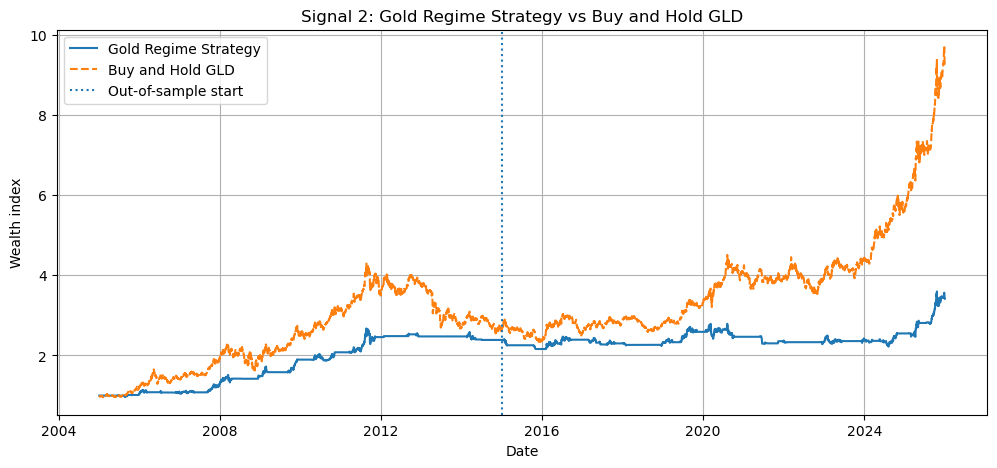

In [5]:
# ============================================================
# Signal 2: Gold regime strategy
# Parameter estimation and evaluation
# ============================================================

signal_2_tickers = [
    "GLD",
    "TLT"
]

signal_2_start_date = "2004-11-18"
signal_2_end_date = "2025-12-31"

signal_2_in_sample_start = "2005-01-01"
signal_2_in_sample_end = "2014-12-31"

signal_2_out_sample_start = "2015-01-01"
signal_2_out_sample_end = "2025-12-31"

df_signal_2_prices, _ = module.download_stock_price_data(
    signal_2_tickers,
    signal_2_start_date,
    signal_2_end_date
)

gold_series = df_signal_2_prices["GLD"]
bond_series = df_signal_2_prices["TLT"]

gold_in_sample = gold_series.loc[
    signal_2_in_sample_start:signal_2_in_sample_end
]

bond_in_sample = bond_series.loc[
    signal_2_in_sample_start:signal_2_in_sample_end
]

gold_out_sample = gold_series.loc[
    signal_2_out_sample_start:signal_2_out_sample_end
]

bond_out_sample = bond_series.loc[
    signal_2_out_sample_start:signal_2_out_sample_end
]

gold_full_sample = gold_series.loc[
    signal_2_in_sample_start:signal_2_out_sample_end
]

bond_full_sample = bond_series.loc[
    signal_2_in_sample_start:signal_2_out_sample_end
]


# ============================================================
# Parameter grid
# ============================================================

trend_windows = [100, 150, 200, 250]

gold_momentum_windows = [63, 126, 168, 210]
gold_momentum_thresholds = [0.00, 0.025, 0.05]

bond_momentum_windows = [63, 126, 168]
bond_momentum_thresholds = [-0.05, -0.02, 0.00]


# ============================================================
# In-sample calibration
# ============================================================

calibration_results = []

for trend_window in trend_windows:
    for gold_momentum_window in gold_momentum_windows:
        for gold_momentum_threshold in gold_momentum_thresholds:
            for bond_momentum_window in bond_momentum_windows:
                for bond_momentum_threshold in bond_momentum_thresholds:

                    signal_frame = module.gold_regime_signal(
                        gold_series=gold_in_sample,
                        bond_series=bond_in_sample,
                        trend_window=trend_window,
                        gold_momentum_window=gold_momentum_window,
                        gold_momentum_threshold=gold_momentum_threshold,
                        bond_momentum_window=bond_momentum_window,
                        bond_momentum_threshold=bond_momentum_threshold
                    )

                    stats, _, _ = evaluate_candidate(
                        gold_in_sample,
                        signal_frame
                    )

                    stats["Trend Window"] = trend_window
                    stats["Gold Momentum Window"] = gold_momentum_window
                    stats["Gold Momentum Threshold"] = gold_momentum_threshold
                    stats["Bond Momentum Window"] = bond_momentum_window
                    stats["Bond Momentum Threshold"] = bond_momentum_threshold

                    calibration_results.append(stats)


df_signal_2_results = pd.DataFrame(calibration_results)

df_signal_2_results["Calibration Score"] = (
    df_signal_2_results["Sharpe Ratio"]
    + df_signal_2_results["Annualized Return"]
)

df_signal_2_results = df_signal_2_results.sort_values(
    by="Calibration Score",
    ascending=False
).reset_index(drop=True)

df_signal_2_results["Rank"] = np.arange(
    1,
    len(df_signal_2_results) + 1
)

print("Signal 2 top 10 parameter combinations:")
display(df_signal_2_results.head(10).round(4))


# ============================================================
# Robustness filters
# ============================================================

df_signal_2_reasonable = df_signal_2_results[
    (df_signal_2_results["Active Share"] >= 0.15)
    & (df_signal_2_results["Active Share"] <= 0.90)
    & (df_signal_2_results["Max Drawdown"] >= -0.40)
    & (df_signal_2_results["Number of Trades"] <= 500)
].copy()

if len(df_signal_2_reasonable) > 0:
    best_signal_2 = df_signal_2_reasonable.iloc[0]
    selection_method_2 = "Best calibration score after robustness filters"
else:
    best_signal_2 = df_signal_2_results.iloc[0]
    selection_method_2 = "Best calibration score without filters"

print("Signal 2 selection method:")
print(selection_method_2)


# ============================================================
# Selected parameters
# ============================================================

signal_2_trend_window = int(best_signal_2["Trend Window"])

signal_2_gold_momentum_window = int(best_signal_2["Gold Momentum Window"])
signal_2_gold_momentum_threshold = float(best_signal_2["Gold Momentum Threshold"])

signal_2_bond_momentum_window = int(best_signal_2["Bond Momentum Window"])
signal_2_bond_momentum_threshold = float(best_signal_2["Bond Momentum Threshold"])

print("Selected Signal 2 parameters:")
print("Trend window:", signal_2_trend_window)
print("Gold momentum window:", signal_2_gold_momentum_window)
print("Gold momentum threshold:", signal_2_gold_momentum_threshold)
print("Bond momentum window:", signal_2_bond_momentum_window)
print("Bond momentum threshold:", signal_2_bond_momentum_threshold)


# ============================================================
# Evaluation with selected parameters
# ============================================================

def make_signal_2(price_series, bond_info_series):

    return module.gold_regime_signal(
        gold_series=price_series,
        bond_series=bond_info_series,
        trend_window=signal_2_trend_window,
        gold_momentum_window=signal_2_gold_momentum_window,
        gold_momentum_threshold=signal_2_gold_momentum_threshold,
        bond_momentum_window=signal_2_bond_momentum_window,
        bond_momentum_threshold=signal_2_bond_momentum_threshold
    )


signal_2_in = make_signal_2(
    gold_in_sample,
    bond_in_sample
)

signal_2_out = make_signal_2(
    gold_out_sample,
    bond_out_sample
)

signal_2_full = make_signal_2(
    gold_full_sample,
    bond_full_sample
)


strategy_2_in, buy_hold_2_in, stats_2_in, bh_2_in = evaluate_signal_curve(
    gold_in_sample,
    signal_2_in
)

strategy_2_out, buy_hold_2_out, stats_2_out, bh_2_out = evaluate_signal_curve(
    gold_out_sample,
    signal_2_out
)

strategy_2_full, buy_hold_2_full, stats_2_full, bh_2_full = evaluate_signal_curve(
    gold_full_sample,
    signal_2_full
)


df_signal_2_statistics = build_statistics_table(
    strategy_name="Gold Regime Strategy",
    buy_hold_name="Buy and Hold GLD",
    in_sample_stats=stats_2_in,
    buy_hold_in_sample_stats=bh_2_in,
    out_sample_stats=stats_2_out,
    buy_hold_out_sample_stats=bh_2_out,
    full_sample_stats=stats_2_full,
    buy_hold_full_sample_stats=bh_2_full
)

display(df_signal_2_statistics)


plot_strategy_vs_buy_hold(
    strategy_curve=strategy_2_full,
    buy_hold_curve=buy_hold_2_full,
    title="Signal 2: Gold Regime Strategy vs Buy and Hold GLD",
    strategy_label="Gold Regime Strategy",
    buy_hold_label="Buy and Hold GLD",
    out_of_sample_start=signal_2_out_sample_start
)

# Summary

The table below collects the main in-sample, out-of-sample and full-sample results for the three strategies.

The purpose of the research notebook is not to recalibrate parameters in the assessment notebook.  
Instead, it documents whether the selected parameters remain useful when evaluated out of sample and compared with simple buy-and-hold exposure to the same underlying ETF.

In [6]:
df_all_statistics = pd.concat(
    [
        df_signal_0_statistics,
        df_signal_1_statistics,
        df_signal_2_statistics
    ],
    axis=0
)

df_all_statistics.round(4)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
SPY VIX Strategy In-Sample,0.0561,0.0722,0.7928,-0.0764
Buy and Hold SPY In-Sample,0.0847,0.2164,0.4837,-0.5519
SPY VIX Strategy Out-of-Sample,0.0720,0.0818,0.8918,-0.1770
Buy and Hold SPY Out-of-Sample,0.1354,0.1779,0.8033,-0.3372
SPY VIX Strategy Full Sample,0.0613,0.0797,0.7863,-0.1770
Buy and Hold SPY Full Sample,0.1130,0.1956,0.6453,-0.5519
Oil Energy Strategy In-Sample,0.0905,0.1444,0.6727,-0.2206
Buy and Hold XLE In-Sample,0.0807,0.2852,0.4153,-0.5736
Oil Energy Strategy Out-of-Sample,0.0453,0.1356,0.3950,-0.4228
Buy and Hold XLE Out-of-Sample,0.0523,0.2937,0.3216,-0.6681
